# What is Inferential Statistics?

Suppose a random variable $X$ describes some phenomenon of interest. Examples include

- the height of a randomly selected person;
- tomorrow's stock return;
- the lifetime of a battery;
- the salary of a software engineer.

Usually, the probability distribution of $X$ is unknown. Instead, we observe only a finite sample

$$
X_1,X_2,\ldots,X_n.
$$

The purpose of inferential statistics is to use this sample to draw conclusions about the unknown probability distribution.

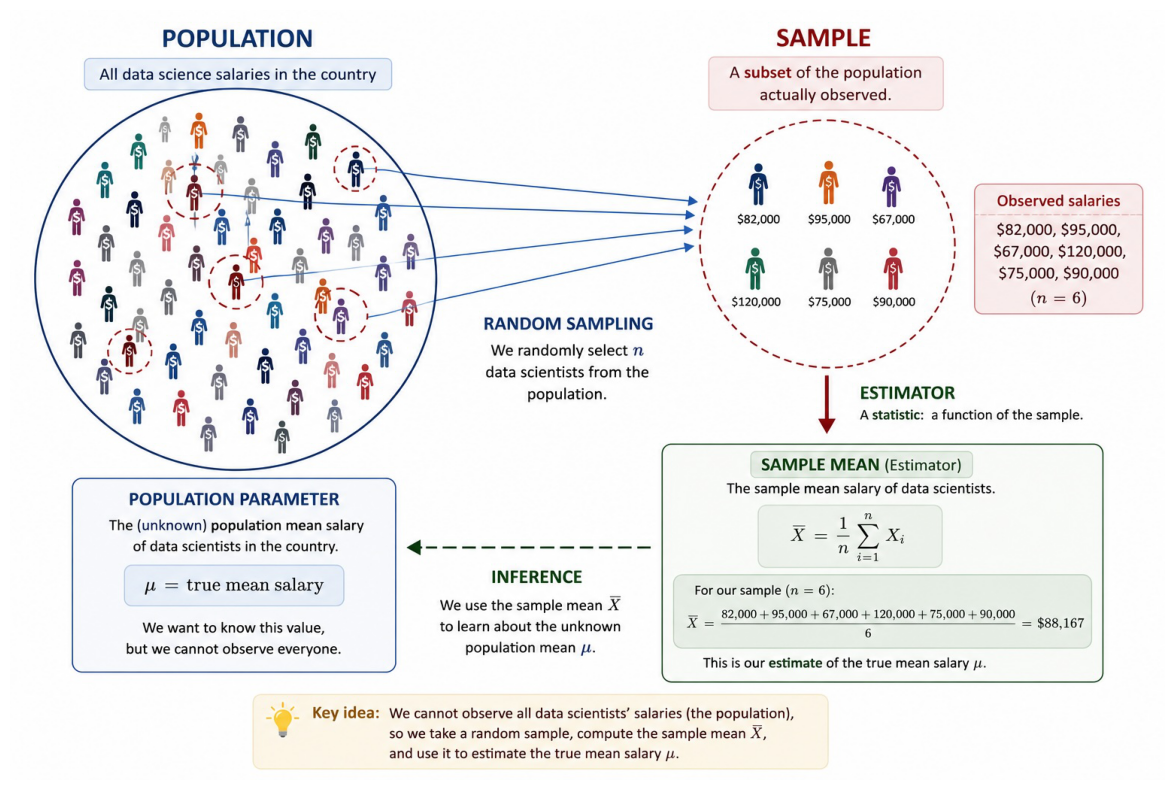

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image = mpimg.imread("images/sample.jpg")

plt.figure(figsize=(14, 8))
plt.imshow(image)
plt.axis("off")
plt.tight_layout()
plt.show()

## Random Sample

The fundamental object in mathematical statistics is a random sample. A random sample of size $n$ is a collection of independent and identically distributed random variables

$$
X_1,\ldots,X_n,
$$

such that $X_i \sim F_\theta$, $i=1,\ldots,n$, where $\theta\in\Theta$ is an unknown parameter.

Notice that  $X_1,\ldots,X_n$ are random variables, not numbers. Only after the experiment is performed do we observe one realization

$$
x_1,\ldots,x_n.
$$

Inference is based entirely on these observations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from IPython.display import display, clear_output
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 12

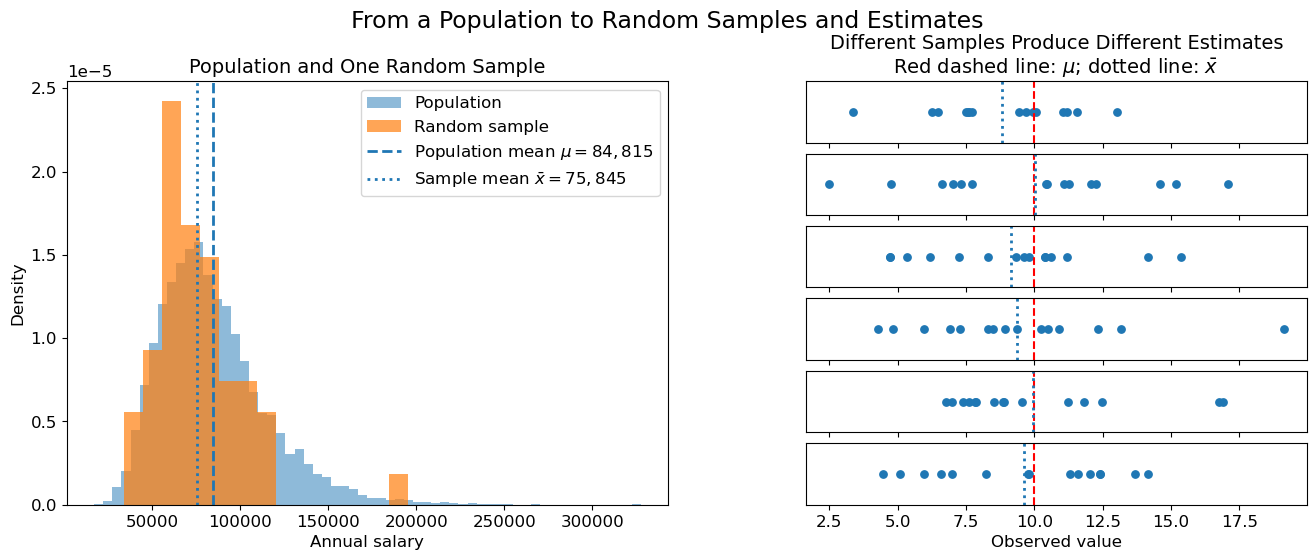

In [23]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ============================================================
# Shared figure
# ============================================================

fig = plt.figure(figsize=(16, 5.5))

outer_grid = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.2, 1],
    wspace=0.25
)

# ============================================================
# Left: Population and one random sample
# ============================================================

ax_population = fig.add_subplot(outer_grid[0, 0])

population_size = 10_000
sample_size = 50

# Synthetic population of annual data-science salaries
population = rng.lognormal(
    mean=np.log(80_000),
    sigma=0.35,
    size=population_size
)

sample_indices = rng.choice(
    population_size,
    size=sample_size,
    replace=False
)

sample = population[sample_indices]

population_mean = population.mean()
sample_mean = sample.mean()

ax_population.hist(
    population,
    bins=60,
    density=True,
    alpha=0.5,
    label="Population"
)

ax_population.hist(
    sample,
    bins=15,
    density=True,
    alpha=0.7,
    label="Random sample"
)

ax_population.axvline(
    population_mean,
    linestyle="--",
    linewidth=2,
    label=rf"Population mean $\mu={population_mean:,.0f}$"
)

ax_population.axvline(
    sample_mean,
    linestyle=":",
    linewidth=2,
    label=rf"Sample mean $\bar{{x}}={sample_mean:,.0f}$"
)

ax_population.set_title(
    "Population and One Random Sample",
    fontsize=14
)

ax_population.set_xlabel("Annual salary")
ax_population.set_ylabel("Density")
ax_population.legend()

# ============================================================
# Right: Six samples produce six different estimates
# ============================================================

mu = 10
sigma = 3
n = 15
number_of_samples = 6

right_grid = outer_grid[0, 1].subgridspec(
    nrows=number_of_samples,
    ncols=1,
    hspace=0.18
)

sample_axes = []

for i in range(number_of_samples):
    ax = fig.add_subplot(
        right_grid[i, 0],
        sharex=sample_axes[0] if sample_axes else None
    )

    sample_axes.append(ax)

    current_sample = rng.normal(mu, sigma, size=n)
    current_sample_mean = current_sample.mean()

    ax.scatter(
        current_sample,
        np.zeros(n),
        s=28
    )

    # True population mean
    ax.axvline(
        mu,
        color="red",
        linestyle="--",
        linewidth=1.5
    )

    # Sample mean
    ax.axvline(
        current_sample_mean,
        linestyle=":",
        linewidth=2
    )

    ax.set_yticks([])

    if i < number_of_samples - 1:
        ax.tick_params(axis="x", labelbottom=False)

sample_axes[0].set_title(
    "Different Samples Produce Different Estimates\n"
    r"Red dashed line: $\mu$; dotted line: $\bar{x}$",
    fontsize=14
)

sample_axes[-1].set_xlabel("Observed value")

fig.suptitle(
    "From a Population to Random Samples and Estimates",
    fontsize=17,
    y=1.01
)

plt.show()

## Statistical Model

A statistical model is a family of probability distributions

$$
\mathcal P
=
\{
P_\theta
:
\theta\in\Theta
\},
$$

indexed by an unknown parameter $\theta$.

Examples include $N(\mu,\sigma^2)$, where $\theta=(\mu,\sigma^2)$, or $\operatorname{Bernoulli}(p)$, where $\theta=p$. Notice that Parameters are **constants**. They are not random variables.

The goal of statistical inference is to estimate the unknown parameter $\theta$ from the observed sample.

## Statistics

A statistic is any measurable function of the sample $X_1,\ldots,X_n$. Formally,

$$
T
=
g(X_1,\ldots,X_n)
$$

for some measurable function $g:\mathbb R^n\to\mathbb R$.

Since the observations are random variables, every statistic is itself a random variable.

Examples include $\bar X$, $S^2$, $X_{(1)}$ and $X_{(n)}$.

# Estimators

An estimator is a statistic whose purpose is to estimate an unknown parameter.

If $\theta$ is the parameter of interest, an estimator is written

$$
\widehat\theta
=
g(X_1,\ldots,X_n).
$$

Notice that

- $\theta$ is a constant;
- $\widehat\theta$ is a random variable.

After observing the sample $x_1,\ldots,x_n$, the estimator takes the numerical value $\hat\theta=g(x_1,\ldots,x_n)$, called the estimate.

## Sampling Distributions

Since every estimator is a random variable, it has its own probability distribution. The probability distribution of an estimator is called its **sampling distribution**.

For example, suppose $ X_1,\ldots,X_n \sim N(\mu,\sigma^2)$. Then the sample mean is itself a random variable satisfying

$$
\bar X
\sim
N\left(
\mu,
\frac{\sigma^2}{n}
\right).
$$

Notice that this distribution is **not** the same as the distribution of a single observation.


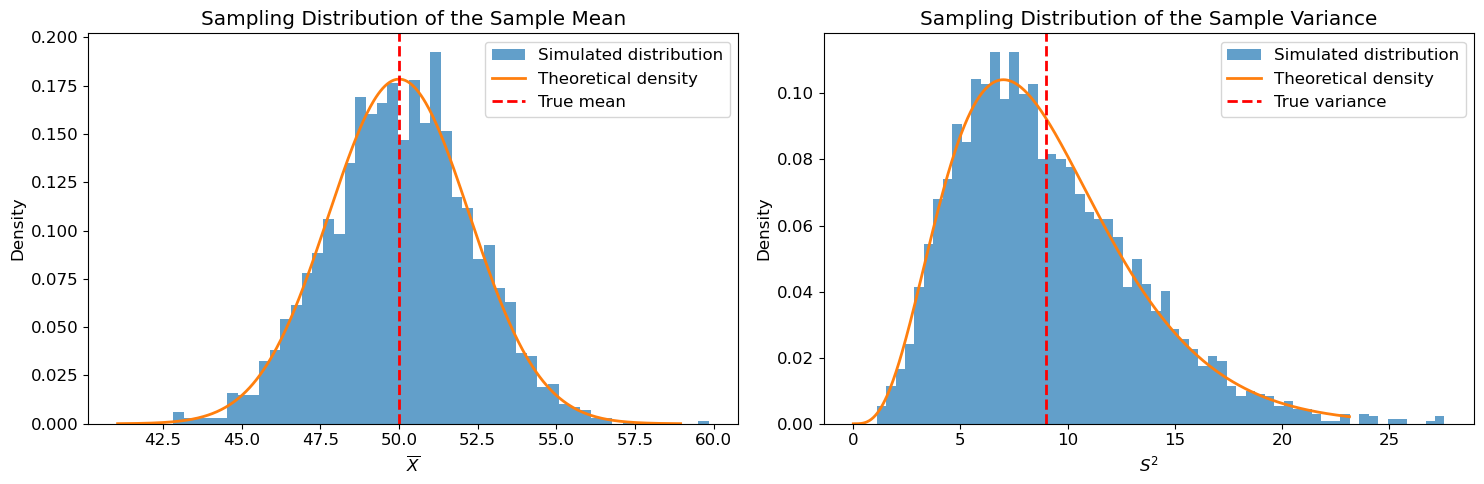

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5)
)

# ============================================================
# LEFT: Sampling distribution of the sample mean
# ============================================================

mu = 50
sigma = 10
n = 20
number_of_simulations = 2_000

samples = rng.normal(
    loc=mu,
    scale=sigma,
    size=(number_of_simulations, n)
)

sample_means = samples.mean(axis=1)

standard_error = sigma / np.sqrt(n)

x = np.linspace(
    mu - 4 * standard_error,
    mu + 4 * standard_error,
    500
)

theoretical_density = stats.norm.pdf(
    x,
    loc=mu,
    scale=standard_error
)

ax = axes[0]

ax.hist(
    sample_means,
    bins=50,
    density=True,
    alpha=0.7,
    label="Simulated distribution"
)

ax.plot(
    x,
    theoretical_density,
    linewidth=2,
    label="Theoretical density"
)

ax.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=2,
    label="True mean"
)

ax.set_title("Sampling Distribution of the Sample Mean")
ax.set_xlabel(r"$\overline{X}$")
ax.set_ylabel("Density")
ax.legend()

# ============================================================
# RIGHT: Sampling distribution of the sample variance
# ============================================================

sigma_squared = 9
sigma = np.sqrt(sigma_squared)
n = 10
number_of_simulations = 3_000

samples = rng.normal(
    loc=0,
    scale=sigma,
    size=(number_of_simulations, n)
)

sample_variances = samples.var(axis=1, ddof=1)

x = np.linspace(
    0,
    np.quantile(sample_variances, 0.995),
    500
)

theoretical_density = (
    stats.chi2.pdf(
        (n - 1) * x / sigma_squared,
        df=n - 1
    )
    * (n - 1)
    / sigma_squared
)

ax = axes[1]

ax.hist(
    sample_variances,
    bins=60,
    density=True,
    alpha=0.7,
    label="Simulated distribution"
)

ax.plot(
    x,
    theoretical_density,
    linewidth=2,
    label="Theoretical density"
)

ax.axvline(
    sigma_squared,
    color="red",
    linestyle="--",
    linewidth=2,
    label="True variance"
)

ax.set_title("Sampling Distribution of the Sample Variance")
ax.set_xlabel(r"$S^2$")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

## Standard Error

The standard error of an estimator is its standard deviation,

$$
SE(\widehat\theta)
=
\sqrt{
\operatorname{Var}(\widehat\theta)
}.
$$

## Properties of Estimators

### Unbiasedness

An estimator $\widehat\theta$ is unbiased if

$$
\operatorname{Bias}(\widehat\theta)
=
0.
$$

Unbiasedness means that, on average, the estimator correctly estimates the true parameter.

### Consistency

An estimator $\widehat\theta_n$ is consistent if

$$
\widehat\theta_n
\overset{P}{\longrightarrow}
\theta.
$$

Consistency guarantees that, as the sample size grows, the estimator approaches the true parameter with high probability.

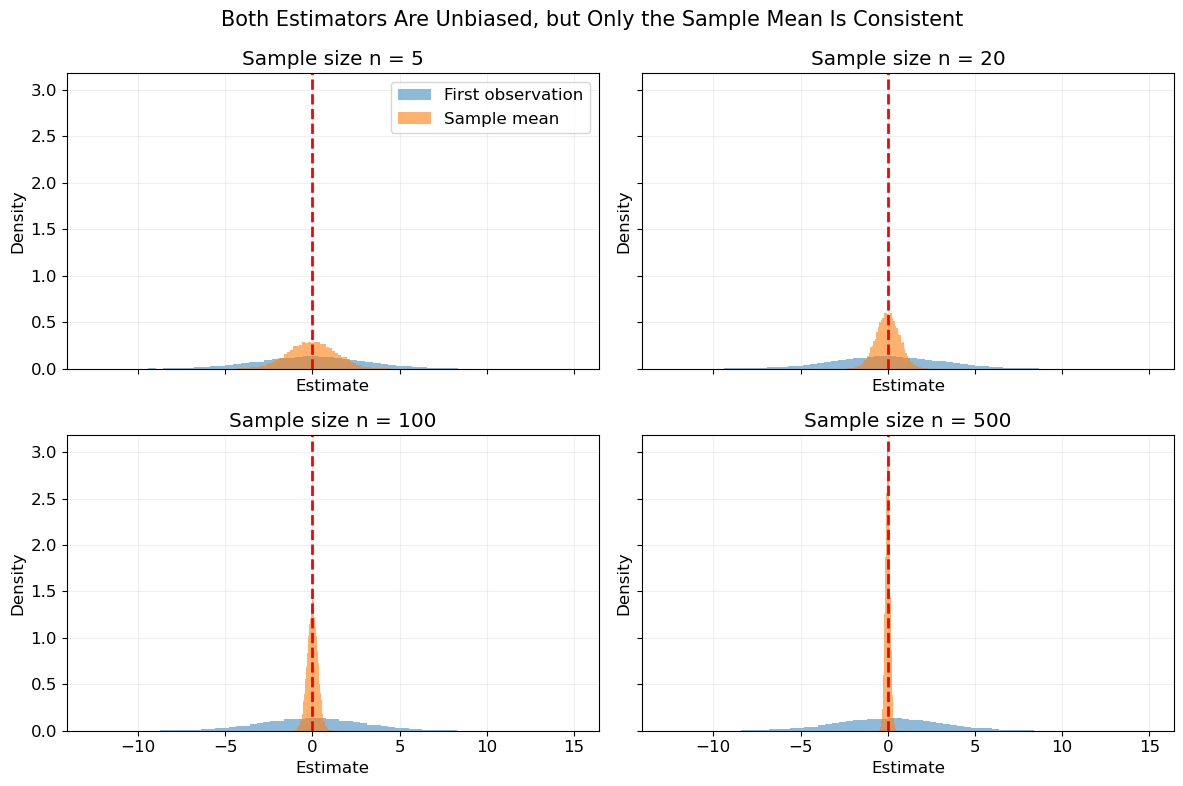

In [48]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

mu = 0
sigma = 3
sample_sizes = [5, 20, 100, 500]
number_of_simulations = 20_000

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, n in zip(axes, sample_sizes):
    samples = rng.normal(
        loc=mu,
        scale=sigma,
        size=(number_of_simulations, n)
    )

    first_observation_estimator = samples[:, 0]
    sample_mean_estimator = samples.mean(axis=1)

    ax.hist(
        first_observation_estimator,
        bins=60,
        density=True,
        alpha=0.5,
        label="First observation"
    )

    ax.hist(
        sample_mean_estimator,
        bins=60,
        density=True,
        alpha=0.6,
        label="Sample mean"
    )

    ax.axvline(
        x=mu,
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Sample size n = {n}")
    ax.set_xlabel("Estimate")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2)

axes[0].legend()

fig.suptitle(
    "Both Estimators Are Unbiased, but Only the Sample Mean Is Consistent",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Asymptotic Normality

An estimator $\widehat\theta_n$ is asymptotically normal if, for some constant $V>0$, 

$$
\sqrt n
(\widehat\theta_n-\theta)
\overset{d}{\longrightarrow}
N(0,V).
$$

Asymptotic normality is one of the most important properties in statistical inference because it allows us to construct confidence intervals and hypothesis tests.

## Examples of Estimators

- The sample mean is defined by

$$
\bar X
=
\frac1n
\sum_{i=1}^nX_i.
$$



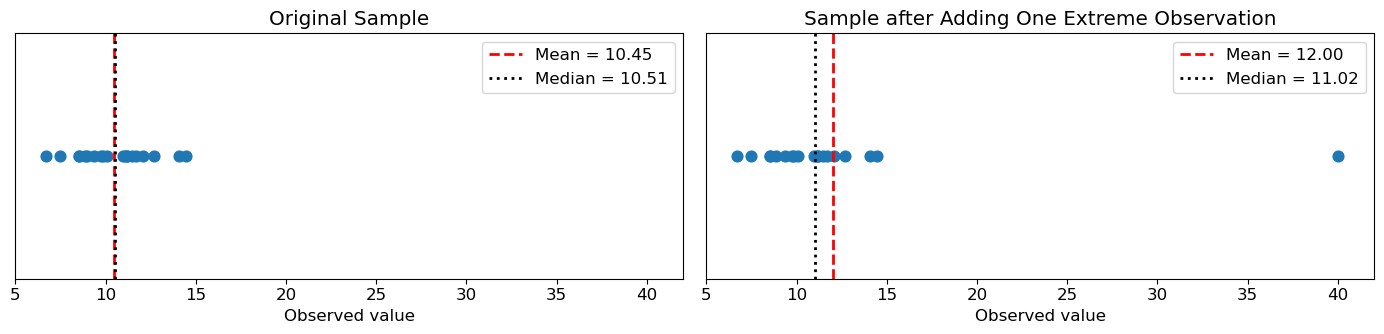

In [60]:
sample = rng.normal(10, 2, size=20)
contaminated_sample = sample.copy()
contaminated_sample[-1] = 40

original_mean = sample.mean()
contaminated_mean = contaminated_sample.mean()

original_median = np.median(sample)
contaminated_median = np.median(contaminated_sample)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 3.5),
    sharey=True
)

# ============================================================
# Original sample
# ============================================================

axes[0].scatter(sample, np.zeros_like(sample), s=60)

axes[0].axvline(
    original_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {original_mean:.2f}"
)

axes[0].axvline(
    original_median,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {original_median:.2f}"
)

axes[0].set_xlim(5, 42)
axes[0].set_title("Original Sample")
axes[0].set_xlabel("Observed value")
axes[0].set_yticks([])
axes[0].legend()

# ============================================================
# Contaminated sample
# ============================================================

axes[1].scatter(contaminated_sample, np.zeros_like(contaminated_sample), s=60)

axes[1].axvline(
    contaminated_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {contaminated_mean:.2f}"
)

axes[1].axvline(
    contaminated_median,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {contaminated_median:.2f}"
)

axes[1].set_xlim(5, 42)
axes[1].set_title("Sample after Adding One Extreme Observation")
axes[1].set_xlabel("Observed value")
axes[1].set_yticks([])
axes[1].legend()

plt.tight_layout()
plt.show()

- The sample variance is defined by

$$
S^2
=
\frac1{n-1}
\sum_{i=1}^n
(X_i-\bar X)^2.
$$

Here we devide by $n-1$ in order to obtained an unbiased estimator.

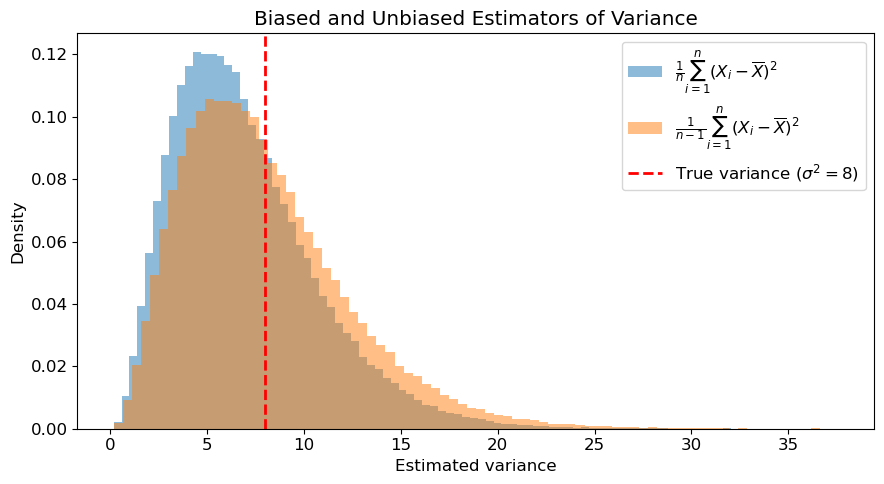

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    biased_variances,
    bins=80,
    density=True,
    alpha=0.5,
    label=r"$\frac{1}{n}\sum_{i=1}^{n}(X_i-\overline{X})^2$"
)

ax.hist(
    unbiased_variances,
    bins=80,
    density=True,
    alpha=0.5,
    label=r"$\frac{1}{n-1}\sum_{i=1}^{n}(X_i-\overline{X})^2$"
)

ax.axvline(
    x=sigma_squared,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"True variance ($\sigma^2={sigma_squared}$)"
)

ax.set_title("Biased and Unbiased Estimators of Variance")
ax.set_xlabel("Estimated variance")
ax.set_ylabel("Density")

ax.legend()
plt.tight_layout()
plt.show()

In [37]:
mu = 0
sigma_squared = 8
sigma = np.sqrt(sigma_squared)

n = 8
number_of_simulations = 100_000

samples = rng.normal(
    mu,
    sigma,
    size=(number_of_simulations, n)
)

biased_variances = samples.var(axis=1, ddof=0)
unbiased_variances = samples.var(axis=1, ddof=1)

print(f"True population variance:             {sigma_squared:.4f}")
print(f"Average variance with denominator n:  {biased_variances.mean():.4f}")
print(f"Average variance with denominator n-1:{unbiased_variances.mean():.4f}")
print()
print(
    "Theoretical expectation with denominator n:",
    (n - 1) / n * sigma_squared
)

True population variance:             8.0000
Average variance with denominator n:  6.9866
Average variance with denominator n-1:7.9847

Theoretical expectation with denominator n: 7.0


- Suppose $X_i \sim \operatorname{Bernoulli}(p)$. The sample proportion is

$$
\widehat p
=
\frac1n
\sum_{i=1}^nX_i.
$$

- Let $X_1,\ldots, X_n$ be a sample. Sorting the observations gives $X_{(1)}\le X_{(2)}\le\cdots\le X_{(n)}$, called the order statistics.

In particular,

- $X_{(1)}$ is the sample minimum;
- $X_{(n)}$ is the sample maximum;
- $X_{(\lceil n/2\rceil)}$ is closely related to the sample median.

## Mean Squared Error

The Mean Squared Error (MSE) measures the overall quality of an estimator. It is defined as

$$
\operatorname{MSE}(\widehat\theta)
=
E[(\widehat\theta-\theta)^2].
$$

Using $E[X^2]=\operatorname{Var}(X)+(E[X])^2$, one obtains the fundamental decomposition

$$
\boxed{
\operatorname{MSE}(\widehat\theta)
=
\operatorname{Var}(\widehat\theta)
+
\operatorname{Bias}(\widehat\theta)^2.
}
$$

This decomposition shows that a good estimator should have both small variance and small bias.

### The Bias-Variance Tradeoff

When constructing an estimator, there are generally two competing objectives. On one hand, we would like the estimator to have **small bias**, so that its average value is close to the true parameter. On the other hand, we would like the estimator to have **small variance**, so that repeated estimates obtained from different samples are similar to one another.

Unfortunately, these two objectives often conflict.

Reducing the variance of an estimator may introduce additional bias, while removing the bias may increase its variability. This phenomenon is known as the **bias-variance tradeoff**, and it is one of the central ideas in modern statistics and machine learning. For this reason, unbiased estimators are not always preferable. In many applications, a slightly biased estimator with substantially smaller variance may produce more accurate estimates overall.

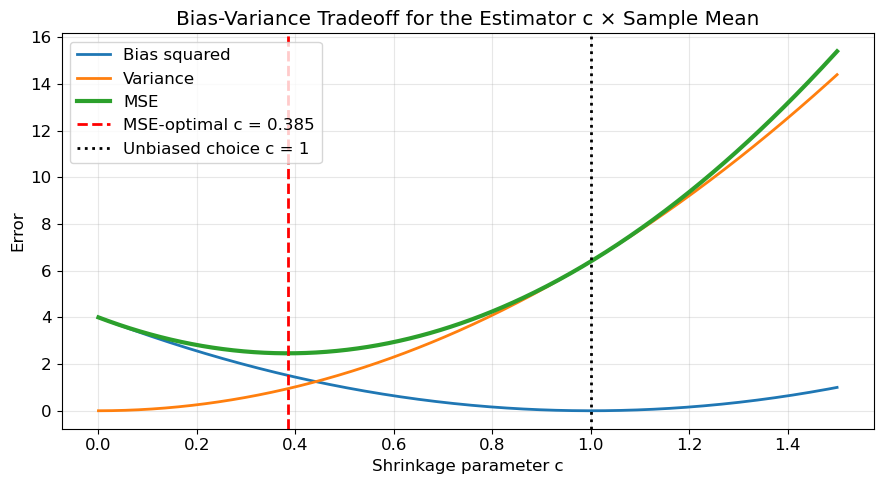

In [43]:
import numpy as np
import matplotlib.pyplot as plt

mu = 2
sigma = 8
n = 10

c_values = np.linspace(0, 1.5, 500)

bias_squared = ((c_values - 1) * mu) ** 2
variance = (c_values ** 2) * (sigma ** 2) / n
mse = bias_squared + variance

optimal_c = (mu ** 2) / (mu ** 2 + (sigma ** 2) / n)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c_values,
    bias_squared,
    linewidth=2,
    label="Bias squared"
)

ax.plot(
    c_values,
    variance,
    linewidth=2,
    label="Variance"
)

ax.plot(
    c_values,
    mse,
    linewidth=3,
    label="MSE"
)

ax.axvline(
    x=optimal_c,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"MSE-optimal c = {optimal_c:.3f}"
)

ax.axvline(
    x=1,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Unbiased choice c = 1"
)

ax.set_title("Bias-Variance Tradeoff for the Estimator c × Sample Mean")
ax.set_xlabel("Shrinkage parameter c")
ax.set_ylabel("Error")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()